In [ ]:
%pip install numpy matplotlib

# Načítaní dat ze složky DATA

Zaklad daně = $\sum přijmy - \sum výdaje$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from funkce import vypocty
from funkce import nacitanisouboru
from funkce import predikce_prijmu_a_vydaju

# Načítáme data z CSV souborů v adresáři "DATA"
slozka_s_daty = "DATA"
vsechna_data = nacitanisouboru.nacti(slozka_s_daty)

print(f"Načteno {len(vsechna_data)} souborů CSV z adresáře '{slozka_s_daty}'.")
dane_jednotlive_mesice = {}
prijmy_predikce = {}
vydaje_predikce = {}
predikovane_dane = {}
nazvy_firem = []
for data_firmy in vsechna_data:
    print(data_firmy)
    dan = vypocty.aktualni_dane(data_firmy["prijmy"], data_firmy["vydaje"])
    dane_jednotlive_mesice[data_firmy["nazev"]] = dan
    prijmy_predikce[data_firmy["nazev"]] = predikce_prijmu_a_vydaju.predikuj_pole(data_firmy["prijmy"])
    vydaje_predikce[data_firmy["nazev"]] = predikce_prijmu_a_vydaju.predikuj_pole(data_firmy["vydaje"])
    predikovane_dane[data_firmy["nazev"]] = vypocty.aktualni_dane(prijmy_predikce[data_firmy["nazev"]], vydaje_predikce[data_firmy["nazev"]])
    nazvy_firem.append(data_firmy["nazev"])

print(dane_jednotlive_mesice)





Načteno 4 souborů CSV z adresáře 'DATA'.
{'nazev': 'firma_pololetni.csv', 'prijmy': array([164277.89, 168650.17, 115715.87, 163963.1 , 204331.07, 238558.59]), 'vydaje': array([59703.06, 52229.23, 56353.21, 91192.24, 60834.52, 68156.26]), 'odvody': array([14000., 14500., 15000., 15500., 16000., 16500.])}
{'nazev': 'firma_rostouci.csv', 'prijmy': array([ 50571.11,  44665.8 ,  77945.81,  98612.86, 107368.74,  74765.4 ,
       137204.39, 150215.29, 106637.38, 139073.9 , 188330.76, 161875.83]), 'vydaje': array([25458.65, 29413.25, 26958.24, 40562.14, 24699.87, 53822.59,
       35523.72, 51032.79, 45624.42, 66371.63, 70874.35, 82286.63]), 'odvody': array([10000., 10500., 11000., 11500., 12000., 12500., 13000., 13500.,
       14000., 14500., 15000., 15500.])}
{'nazev': 'firma_sezonni.csv', 'prijmy': array([ 41066.58,  35936.33,  20405.73,  21551.2 ,  27842.72, 135183.2 ,
       191757.07, 149873.97,  38101.57,  41446.34,  21768.95, 144813.83]), 'vydaje': array([11773.97, 11602.53, 12518.87, 1

# Predikované data 

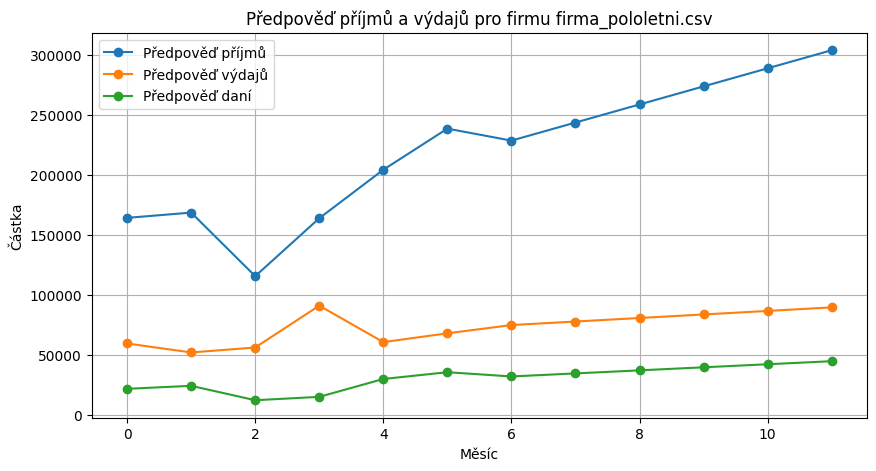

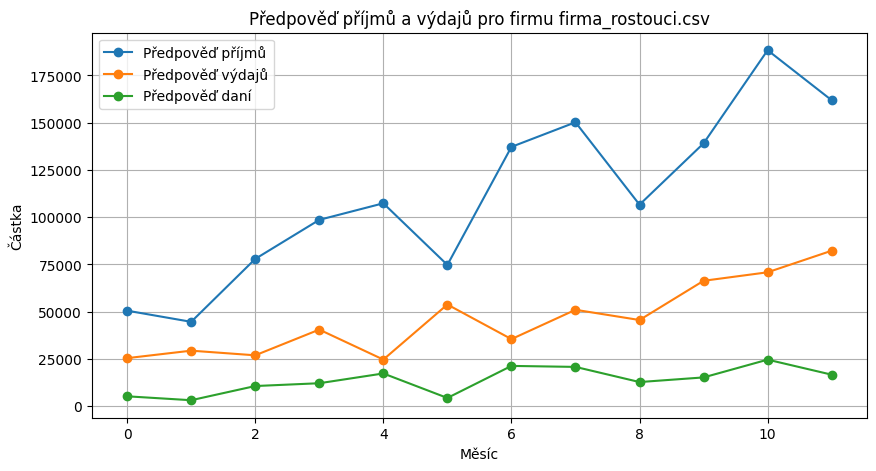

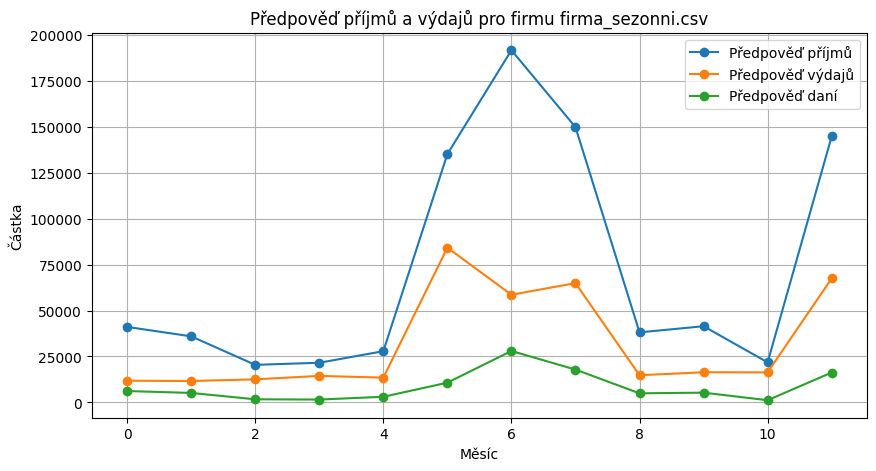

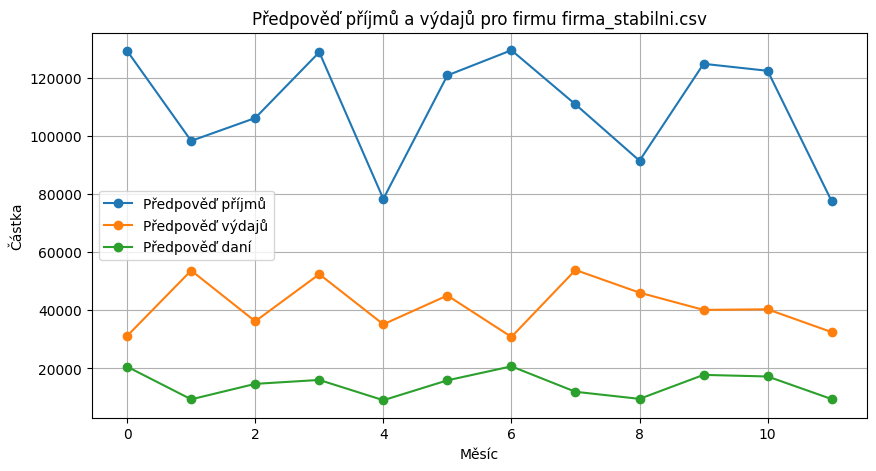

In [2]:

for firma in nazvy_firem:
    plt.figure(figsize=(10, 5))
    plt.plot(prijmy_predikce[firma], label='Předpověď příjmů', marker='o')
    plt.plot(vydaje_predikce[firma], label='Předpověď výdajů', marker='o')
    plt.plot(predikovane_dane[firma], label='Předpověď daní', marker='o')
    plt.title(f'Předpověď příjmů a výdajů pro firmu {firma}')
    plt.xlabel('Měsíc')
    plt.ylabel('Částka')
    plt.legend()
    plt.grid()
    plt.show()

# Porovní predikovných dat s minulýmy 

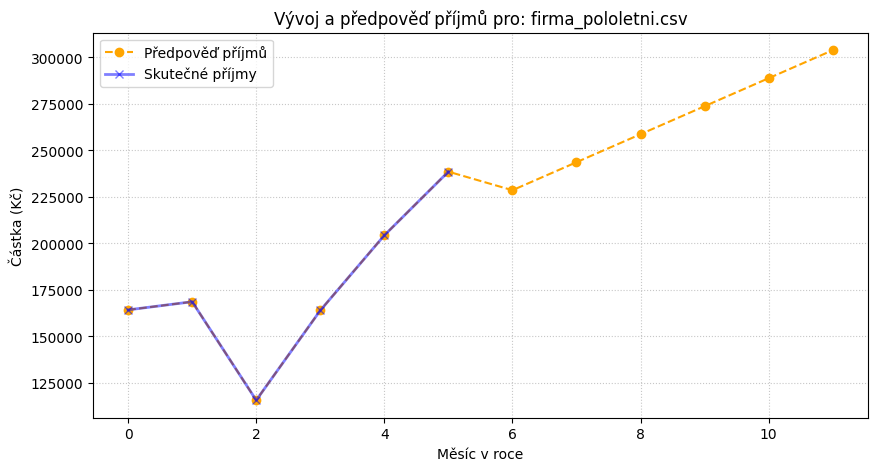

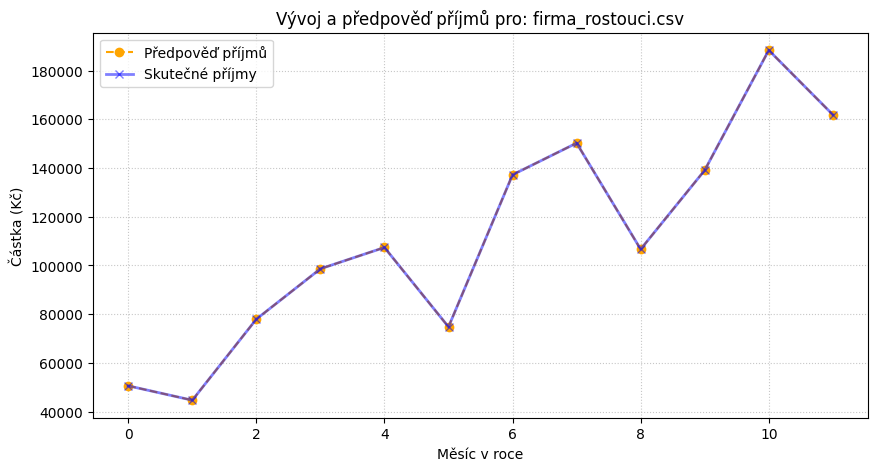

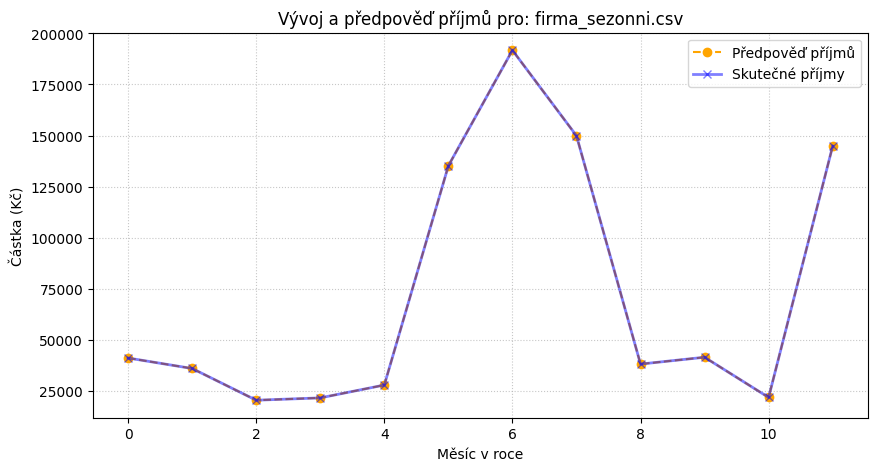

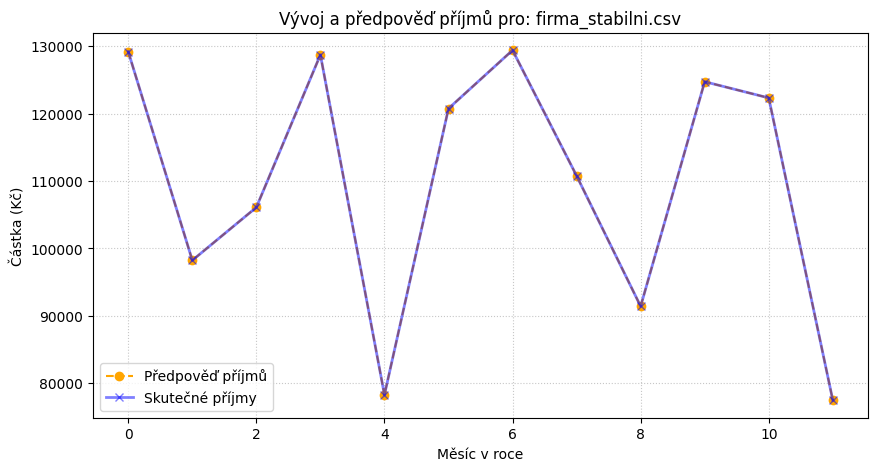

In [ ]:
for data_firmy in vsechna_data:
    firma = data_firmy["nazev"] 
    plt.figure(figsize=(10, 5))

    plt.plot(prijmy_predikce[firma], label='Předpověď příjmů', marker='o', color='orange', alpha=1, linestyle='--')
    
    plt.plot(data_firmy["prijmy"], label='Skutečné příjmy', marker='x', color='blue', alpha=0.5, linewidth=2)
    
    plt.title(f'Vývoj a předpověď příjmů pro: {firma}')
    plt.xlabel('Měsíc v roce')
    plt.ylabel('Částka (Kč)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()